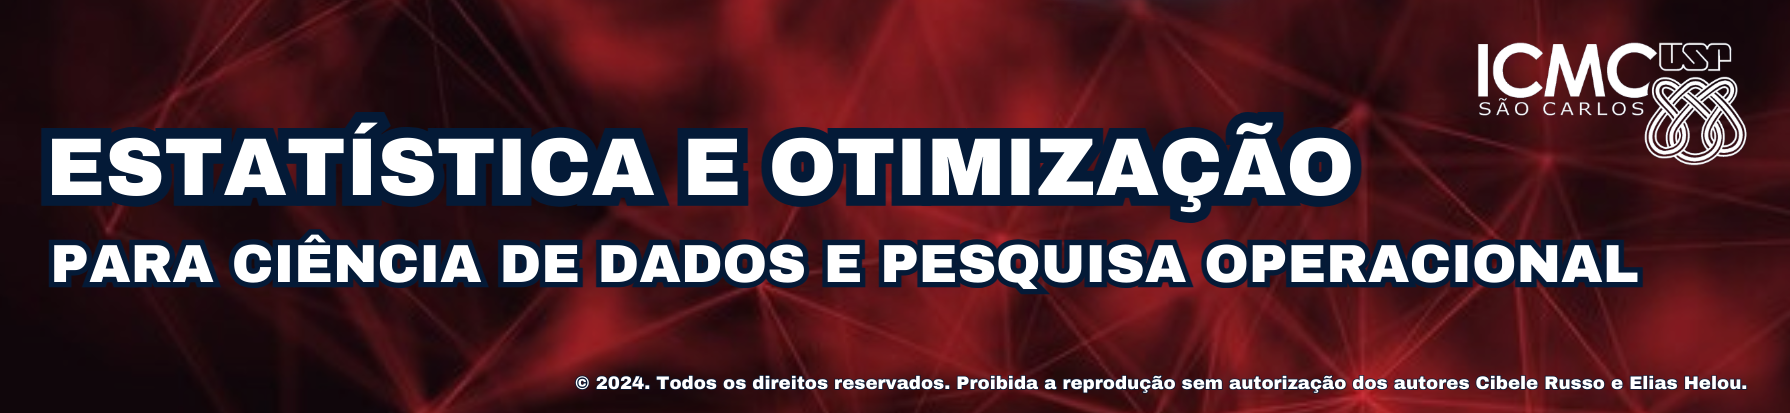


# Testes de hipóteses

por **Cibele Russo**

**ICMC/USP - São Carlos SP**





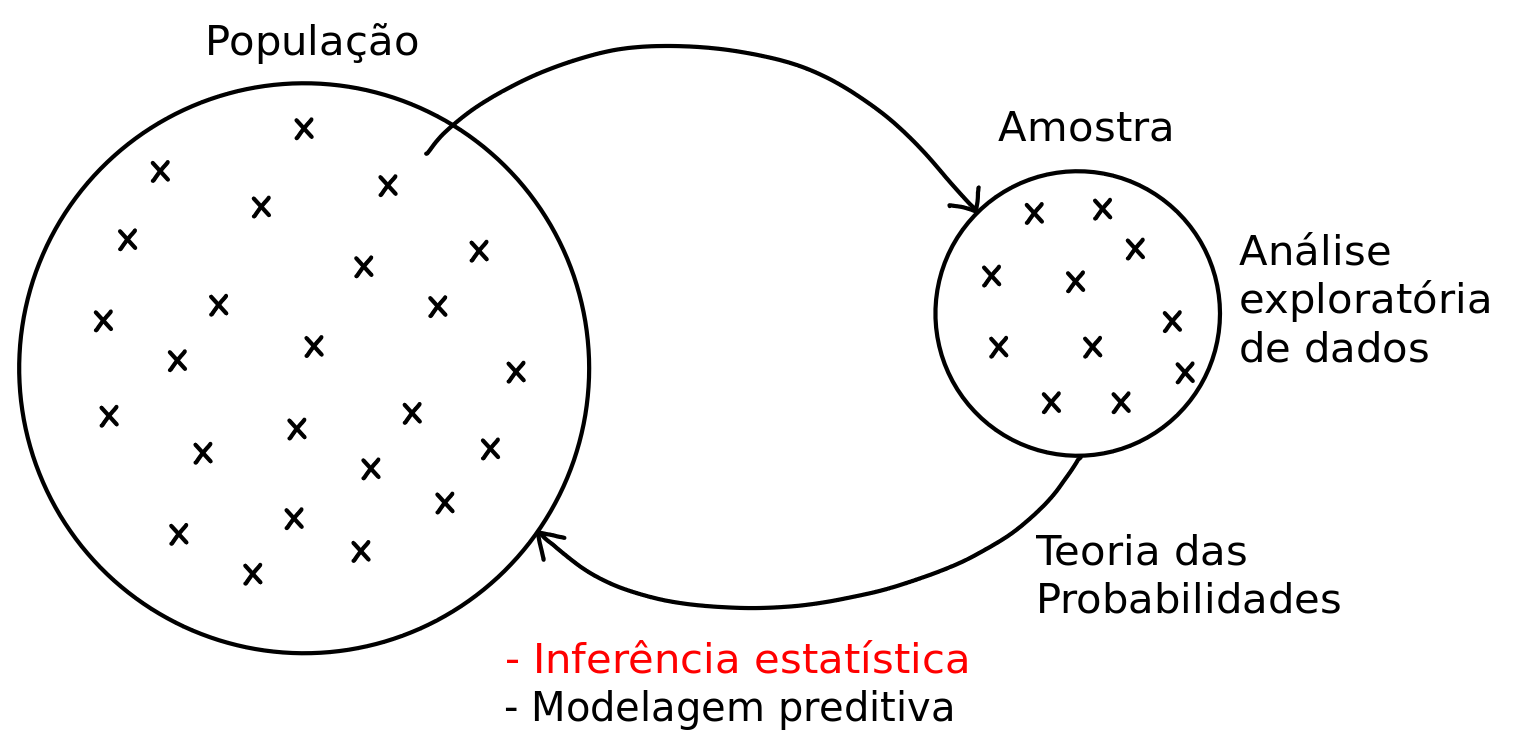

## Motivação: as diferenças observadas no conjunto de dados tem significância estatística?

### Retomando os dados da Aula 1

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')  # Ignora todos os warnings

%matplotlib inline

# Modifique o diretório para fazer a leitura dos dados em DadoseDecisoes.csv
url = "https://raw.githubusercontent.com/cibelerusso/Datasets/refs/heads/main/DadoseDecisoes.csv"

# Dados banco - Leitura dos dados
dados = pd.read_csv(url, index_col=0)

# Para fins didáticos, vamos tomar uma amostra de tamanho 100 (ajuste conforme necessário)
n = 100  # Defina o tamanho da amostra desejado
dados = dados.sample(n=n, random_state=42)


In [2]:
dados.groupby(by='Departamento')['Produtividade'].describe()

,count,mean,std,min,25%,50%,75%,max
Departamento,,,,,,,,
Marketing,19.0,93.151053,12.672539,68.78,85.8150,93.48,104.8850,110.83
RH,22.0,84.967727,14.343788,65.74,71.9100,82.88,98.6375,109.38
TI,32.0,88.624062,11.699240,68.41,78.3975,88.42,97.8475,106.89
Vendas,27.0,90.002963,13.055434,67.33,81.6800,87.04,103.3400,111.03


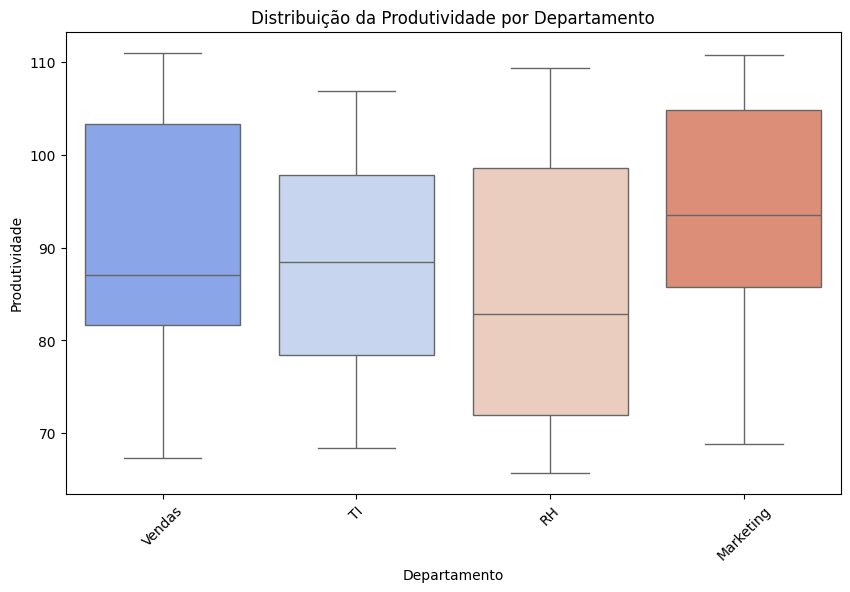

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Análise exploratória de dados
plt.figure(figsize=(10, 6))
sns.boxplot(x='Departamento', y='Produtividade', data=dados, palette='coolwarm')

plt.xticks(rotation=45)  # Rotacionar os rótulos do eixo X se houver muitos departamentos
plt.xlabel('Departamento')
plt.ylabel('Produtividade')
plt.title('Distribuição da Produtividade por Departamento')

# Exibir o gráfico
plt.show()


### Objetivo: Avaliar a significância estatística de um resultado observado na amostra.

Testes paramétricos (supõe normalidade):

- Teste para a média com variância conhecida
- Teste para a média com variância desconhecida
- Teste para a variância
- Teste para a comparação de médias em duas amostras dependentes (teste t pareado)
- Teste para a comparação de médias em duas amostras independentes (teste t independente)
- Teste para a comparação de variâncias
- Teste para a comparação de médias em três ou mais amostras independentes (ANOVA)


Testes não-paramétricos

- Teste Qui-quadrado
- Teste para a comparação de duas amostras dependentes
- Teste para a comparação de duas amostras independentes
- Teste para a comparação de três ou mais amostras

## Passos para Realizar um Teste de Hipóteses

Os passos para realizar um teste de hipóteses paramétrico são os seguintes:

1. **Definir a variável aleatória** em estudo e a distribuição cujo parâmetro se deseja testar.

2. **Definir as hipóteses:**
    - Hipótese nula ($H_0$): A hipótese inicial que se assume ser verdadeira, em geral a hipótese mais simples.
    - Hipótese alternativa ($H_1$): A hipótese que se deseja testar e que é alternativa à hipótese nula.
   
   
3. **Escolher o nível de significância ($\alpha$):**
    O nível de significância é o risco de rejeitar a hipótese nula quando ela é verdadeira. Comumente, $\alpha$ é 0.05, ou seja, 5\% de chance de cometer um erro tipo I (rejeitar $H_0$ quando ela é verdadeira).
    

4. **Escolher o teste estatístico:**

    Dependendo do tipo de dado e do problema, escolhe-se o teste adequado.
    
    Por exemplo,
        - Teste z, se a variância é conhecida e a amostra é grande.
        - Teste t, se a variância é desconhecida e a amostra é pequena.

5. **Calcular a estatística de teste:**

    A estatística de teste depende do tipo de teste escolhido.
    
    Para os testes paramétricos, a estatística de teste tem distribuição normal ou t-Student para avaliar médias, qui-quadrado para avaliar variância, F de Fisher-Snedecor para avaliar razões de variâncias.

6. **Determinar a região de rejeição:**

    A região de rejeição é baseada no valor crítico da distribuição da estatística de teste, que depende do nível de significância $\alpha$:

7. **Tomar a decisão:**

Comparar a estatística de teste com o valor crítico:
    - Se o valor calculado da estatística de teste cair na região de rejeição, rejeitamos $H_0$.
    - Se o valor calculado da estatística de teste não cair na região de rejeição, não rejeitamos $H_0$.

8. **Conclusão do teste:**
    Baseado na decisão tomada, concluir se há ou não evidências suficientes para rejeitar a hipótese nula $H_0$ em favor da hipótese alternativa $H_1$.


## Teste para média populacional

Para testar se a média populacional $\mu$ de uma variável $X$ com distribuição normal é igual a um valor específico $\mu_0$, formulamos as seguintes hipóteses:


#### Hipóteses:

- Teste bicaudal:

$\begin{aligned}
    H_0 &: \mu = \mu_0 \\
    H_1 &: \mu \neq \mu_0
\end{aligned}$        
    
    

- Teste unicaudal superior:

$\begin{aligned}
    H_0 &: \mu = \mu_0 \\
    H_1 &: \mu > \mu_0
\end{aligned}$  


- Teste unicaudal inferior:

$\begin{aligned}
    H_0 &: \mu = \mu_0 \\
    H_1 &: \mu < \mu_0
\end{aligned}$  

    
    
**Estatística de Teste:**


Se $X \sim \mathcal{N}(\mu, \sigma^2)$ e temos uma amostra aleatória de tamanho $n$, a estatística de teste é dada por

$
Z = \displaystyle\frac{\bar{X} - \mu_0}{\displaystyle\frac{\sigma}{\sqrt{n}}}
 \sim \mathcal{N}(0,1)$, quando a variância $\sigma^2$ é conhecida e

$
T = \displaystyle\frac{\bar{X} - \mu_0}{\displaystyle\frac{s}{\sqrt{n}}} \sim \text{t-Student}_{n-1}
$ quando quando a variância $\sigma^2$ é desconhecida

onde:
- $\bar{X}$ é a média amostral,
- $s$ é o desvio padrão amostral,
- $n$ é o tamanho da amostra.



**Decisão do Teste:**


- Comparar $T$ ou $Z$ com os valores críticos da distribuição correspondente (t-Student ou Normal).
- Se o p-valor for menor que o nível de significância $\alpha$ (exemplo: $0.05$), rejeitamos $H_0$.




### Teste para Variância Populacional


Para testar se a variância populacional $\sigma^2$ de uma variável $X$ com distribuição normal é igual a um valor específico $\sigma_0^2$, formulamos as seguintes hipóteses:

Hipóteses

Teste bicaudal

$
\begin{aligned}
    H_0 &: \sigma^2 = \sigma_0^2 \\
    H_1 &: \sigma^2 \neq \sigma_0^2
\end{aligned}
$

Teste unicaudal superior

$
\begin{aligned}
    H_0 &: \sigma^2 = \sigma_0^2 \\
    H_1 &: \sigma^2 > \sigma_0^2
\end{aligned}
$

Teste unicaudal inferior

$
\begin{aligned}
    H_0 &: \sigma^2 = \sigma_0^2 \\
    H_1 &: \sigma^2 < \sigma_0^2
\end{aligned}
$

**Estatística de Teste**

Se $X \sim \mathcal{N}(\mu, \sigma^2)$ e temos uma amostra aleatória de tamanho $n$, a estatística de teste é dada por:

$
\chi^2 = \displaystyle\frac{(n-1) S^2}{\sigma_0^2} \sim \chi^2_{n-1}
$

onde:
- $S^2$ é a variância amostral,
- $n$ é o tamanho da amostra,
- $\chi^2_{n-1}$ representa a distribuição qui-quadrado com $n-1$ graus de liberdade.
}

**Decisão do Teste**

- Comparar o valor da estatística $\chi^2$ com os valores críticos da distribuição qui-quadrado para o nível de significância $\alpha$.
- Se o p-valor for menor que $\alpha$ (exemplo: $0.05$), rejeitamos $H_0$.



### Exemplo: Teste para a média de uma população com a variância conhecida

$X_i$: Produtividade do $i$-ésimo funcionário de TI

$X_i \sim N(\mu, \sigma^2)$ com $\sigma^2$ conhecido

$X_1, \ldots, X_n$ amostra aleatória

Considere avaliar

$H_0: \mu = \mu_0$ contra

$H_1: \mu < \mu_0$

$RC = \{\bar{x} \in \mathbb{R}; \bar{x}< x_c\}$

Exemplo

$H_0: \mu =100$ contra

$H_1: \mu < 100$

$RC = \{\bar{x} \in \mathbb{R}; \bar{x}< x_c\}$

In [4]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

In [5]:
ProdutividadeTI = dados.loc[dados['Departamento']=='TI']['Produtividade']

## Teste de normalidade dos dados: Shapiro Wilk

#### Atenção! Para usar testes paramétricos, testar a normalidade dos dados antes!

$X_1, \ldots, X_n$ amostra aleatória

$H_0: X_i \sim Normal$ contra

$H_1:  X_i $ tem outra distribuição


In [6]:
from scipy import stats
# Teste Shapiro-Wilk para normalidade

shapiro_test = stats.shapiro(np.asarray(ProdutividadeTI))
shapiro_test

ShapiroResult(statistic=np.float64(0.9447193721983149), pvalue=np.float64(0.10197031865898937))

In [7]:
#decisão do teste

if shapiro_test.pvalue < 0.05: print ('Rejeito H0: os dados não apresentam normalidade')
else: print ('Não rejeito H0: os dados podem ser considerados normais')

Não rejeito H0: os dados podem ser considerados normais


In [8]:
ProdutividadeTI.std()

11.699240079918896

In [9]:
# Dados do exercício

mu0 = 100
sigma = 12
n=len(ProdutividadeTI)

xc = norm.ppf(0.05)*(sigma/np.sqrt(n)) + mu0

print('RC = {xbarra <', np.round(xc,2), '}')

RC = {xbarra < 96.51 }


In [10]:
# xbarra observado e decisão do teste

xbarra = ProdutividadeTI.mean()

print('xbarra=', xbarra)

if xbarra < xc: print ('Rejeito H0: a produtividade média em TI não pode ser considerada 100')
else: print('Não rejeito H0: a produtividade média em TI pode ser considerada 100')



xbarra= 88.6240625
Rejeito H0: a produtividade média em TI não pode ser considerada 100


In [11]:
xbarra

np.float64(88.6240625)

In [12]:
# Nível descritivo do teste
z_obs = (xbarra - mu0)/(sigma/np.sqrt(n))

print('valor-p', np.round(norm.cdf(z_obs),10))

valor-p 4.1e-08


### Exemplo: Teste a média de uma população com a variância desconhecida

Vamos agora supor que a variância dos dados é desconhecida

$X_i$: Produtividade do $i$-ésimo funcionário de TI

$X_i \sim N(\mu, \sigma^2)$ com $\sigma^2$ desconhecido

$X_1, \ldots, X_n$ amostra aleatória

Considere avaliar

$H_0: \mu =\mu_0$ contra

$H_1: \mu<\mu_0$

$RC = \{T \in \mathbb{R}; T < t_c\}$

Exemplo:

$H_0: \mu =100$ contra

$H_1: \mu<100$


In [13]:
from scipy.stats import t
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Dados do exercício

mu0 = 100
s = ProdutividadeTI.std()
n=len(ProdutividadeTI)

tc = t.ppf(0.05, n-1)*(s/np.sqrt(n)) + mu0

print('RC = {t <', np.round(xc,2), '}')

RC = {t < 96.51 }


In [15]:
# t observado e decisão do teste

tobs = ProdutividadeTI.mean()

print('tobs=', tobs)

if tobs < tc: print ('Rejeito H0: a produtividade média em TI não pode ser considerada 100')
else: print('Não rejeito H0: a produtividade média em TI pode ser considerada 100')

tobs= 88.6240625
Rejeito H0: a produtividade média em TI não pode ser considerada 100


In [16]:
# Nível descritivo do teste

tobs = (xbarra - mu0)/(s/np.sqrt(n))

print('valor-p', np.round(t.cdf(tobs, n-1),20))

valor-p 2.55621289023016e-06


## Teste para variância de uma população

Considere avaliar

$H_0: \sigma^2 = \sigma^2_0$ contra

$H_1: \sigma^2 \neq \sigma^2_0$.

Usamos a estatística baseada na variância amostral observada $s^2$

$v = \displaystyle\frac{(n-1)S^2}{\sigma^2_0}$

$RC = \{v \in \mathbb{R}^+; v < v_{c1} \text{  ou  }  v > v_{c2}\}$

In [17]:
ProdutividadeTI.var()

136.87221844758068

In [18]:
from scipy.stats import chi2

s2 = ProdutividadeTI.var()
sigma2_0 = 100
n = len(ProdutividadeTI)

vobs = (n-1) * s2 / sigma2_0

vc1 = chi2.ppf(0.025, n-1)
vc2 = chi2.ppf(0.975, n-1)

print('vobs = ', vobs, '\nRC = {v <', np.round(vc1,2), 'ou v >', np.round(vc2,2), '}')

if ((vobs > vc2) or (vobs < vc1)) : print ('Rejeito H0.')
else: print('Não rejeito H0.')

vobs =  42.430387718750005 
RC = {v < 17.54 ou v > 48.23 }
Não rejeito H0.


## Testes de comparação de médias

### Qual teste escolher?

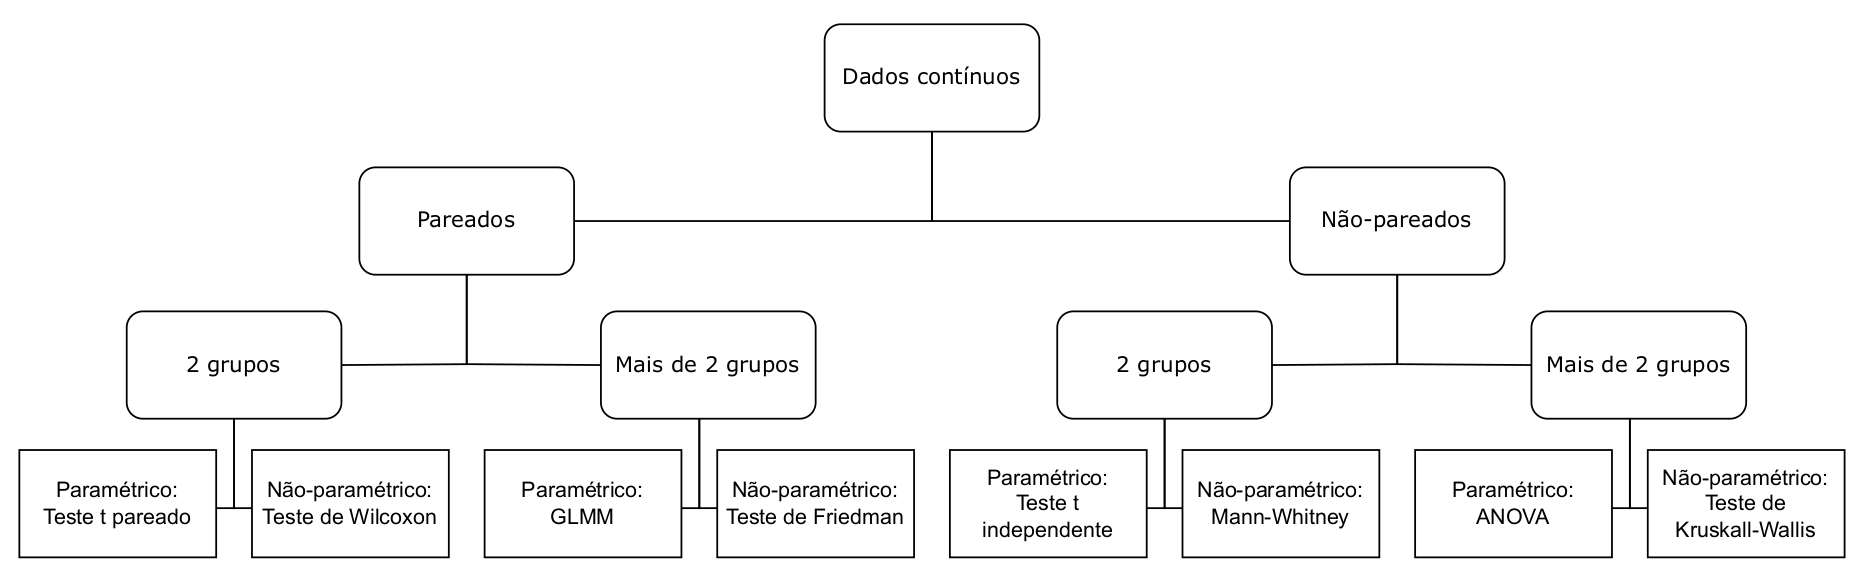


### Teste para média de duas populações independentes


Para comparar as médias de duas populações **independentes** com distribuição normal e variâncias populacionais conhecidas, queremos testar:

$
H_0: \mu_1 = \mu_2
$

contra a hipótese alternativa:

$
H_1: \mu_1 < \mu_2
$

Seja $X_1 \sim \mathcal{N}(\mu_1, \sigma_1^2)$ e $X_2 \sim \mathcal{N}(\mu_2, \sigma_2^2)$, com amostras aleatórias $X_{11}, \dots, X_{1n_1}$ e $X_{21}, \dots, X_{2n_2}$ extraídas dessas populações.

A diferença entre as médias amostrais segue a distribuição:

$
\bar{X}_1 - \bar{X}_2 \sim \mathcal{N}(\mu_1 - \mu_2, \sigma^2_{\bar{X}_1 - \bar{X}_2})
$

onde

$
\sigma^2_{\bar{X}_1 - \bar{X}_2} = \displaystyle\frac{\sigma_1^2}{n_1} + \displaystyle\frac{\sigma_2^2}{n_2}
$

A estatística de teste é dada por:

$
Z =\displaystyle \frac{\bar{X}_1 - \bar{X}_2}{\displaystyle\sqrt{\displaystyle\frac{\sigma_1^2}{n_1} + \displaystyle\frac{\sigma_2^2}{n_2}}}
$

que segue a distribuição normal padrão $Z \sim \mathcal{N}(0,1)$.

**Região Crítica**

A região crítica fornecida no problema:

$
RC = \{\bar{x}_1 - \bar{x}_2 \in \mathbb{R} ; \bar{x}_1 - \bar{x}_2 < x_c\}
$

pode ser expressa como:

$
x_c = z_{\alpha} \displaystyle\sqrt{\displaystyle\frac{\sigma_1^2}{n_1} + \displaystyle\frac{\sigma_2^2}{n_2}}
$

Rejeitamos $H_0$ se:

$
\bar{X}_1 - \bar{X}_2 < z_{\alpha} \displaystyle\sqrt{\displaystyle\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}}
$


## Teste t independente


Em geral, nas aplicações as **variâncias são desconhecidas**. Nesse caso, a diferença entre as médias amostrais segue aproximadamente uma distribuição t de Student com \( v \) graus de liberdade:

$
\bar{X}_1 - \bar{X}_2 \sim t_v
$

onde os graus de liberdade são aproximados por:

$
v = \frac{\left( \frac{s_1^2}{n_1} + \frac{s_2^2}{n_2} \right)^2}{\frac{ \left(\frac{s_1^2}{n_1} \right)^2 }{n_1 - 1} + \frac{\left(\frac{s_2^2}{n_2} \right)^2 }{n_2 - 1}}
$

A estatística de teste é dada por:

$
t =\displaystyle \frac{\bar{X}_1 - \bar{X}_2}{\displaystyle\sqrt{\displaystyle\frac{s_1^2}{n_1} + \displaystyle\frac{s_2^2}{n_2}}}
$

que segue a distribuição \( t_v \) com \( v \) graus de liberdade.

**Região Crítica**

A região crítica fornecida no problema:

$
RC = \{\bar{x}_1 - \bar{x}_2 \in \mathbb{R} ; \bar{x}_1 - \bar{x}_2 < t_{\alpha, v} \}
$

pode ser expressa como:

$
t_{\alpha, v} = \text{percentil inferior da distribuição } t_v
$

Rejeitamos \(H_0\) se:

$
\bar{X}_1 - \bar{X}_2 < t_{\alpha, v} \cdot \displaystyle\sqrt{\displaystyle\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}
$


In [19]:
departamentos = dados['Departamento'].unique()
departamentos

array(['Vendas', 'TI', 'RH', 'Marketing'], dtype=object)

In [20]:
# Teste de normalidade para cada grupo
departamentos = dados['Departamento'].unique()
for depto in departamentos:
    grupo = dados[dados['Departamento'] == depto]['Produtividade']
    stat, p_value = stats.shapiro(grupo)  # Teste de Shapiro-Wilk
    print(f"Teste de normalidade para {depto}: estatística={stat:.4f}, p-valor={p_value:.4f}")

# Teste para comparar a produtividade em Vendas e TI
grupo1 = dados[dados['Departamento'] == departamentos[0]]['Produtividade']
grupo2 = dados[dados['Departamento'] == departamentos[1]]['Produtividade']

# Se não rejeitarmos a normalidade, vamos usar testes paramétricos
if stats.shapiro(grupo1).pvalue > 0.05 and stats.shapiro(grupo2).pvalue > 0.05:
    stat, p_value = stats.ttest_ind(grupo1, grupo2, equal_var=False)  # Teste t de Student
    print(f"Teste t de Student: estatística={stat:.4f}, p-valor={p_value:.4f}")
else:
    stat, p_value = stats.mannwhitneyu(grupo1, grupo2, alternative='two-sided')  # Teste de Mann-Whitney
    print(f"Teste de Mann-Whitney: estatística={stat:.4f}, p-valor={p_value:.4f}")


Teste de normalidade para Vendas: estatística=0.9425, p-valor=0.1404
Teste de normalidade para TI: estatística=0.9447, p-valor=0.1020
Teste de normalidade para RH: estatística=0.9202, p-valor=0.0768
Teste de normalidade para Marketing: estatística=0.9437, p-valor=0.3069
Teste t de Student: estatística=0.4237, p-valor=0.6735


### Exemplo: Teste t para populações independentes

In [21]:
dados.groupby(by='Departamento')['Produtividade'].describe()

,count,mean,std,min,25%,50%,75%,max
Departamento,,,,,,,,
Marketing,19.0,93.151053,12.672539,68.78,85.8150,93.48,104.8850,110.83
RH,22.0,84.967727,14.343788,65.74,71.9100,82.88,98.6375,109.38
TI,32.0,88.624062,11.699240,68.41,78.3975,88.42,97.8475,106.89
Vendas,27.0,90.002963,13.055434,67.33,81.6800,87.04,103.3400,111.03


In [22]:
x=dados.loc[dados['Departamento'] == 'RH']['Produtividade']
y=dados.loc[dados['Departamento'] == 'Marketing']['Produtividade']


In [23]:
# Média amostral de x
np.mean(x)


np.float64(84.96772727272729)

In [24]:
# Média amostral de y
np.mean(y)


np.float64(93.15105263157895)

In [25]:
# Desvio-padrão de x
np.std(x)

14.014002066705277

In [26]:
# Desvio-padrão de y
np.std(y)

12.334543233809011

Qual é o caso?

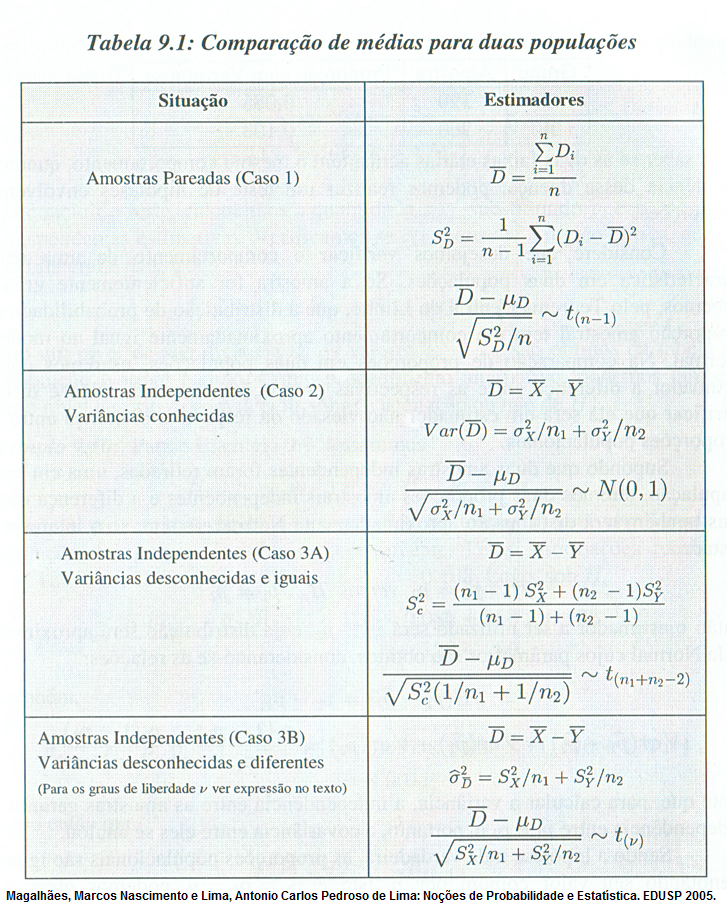

Caso 2: variâncias conhecidas

Caso 3a: variâncias desconhecidas e iguais

Caso 3b: variâncias desconhecidas e diferentes

## Teste F para igualdade de variâncias de duas populações

Considere avaliar

$H_0: \sigma^2_1 = \sigma^2_2$ contra

$H_1: \sigma^2_1 \neq \sigma^2_2$.

Usamos a estatística baseada nas variâncias amostrais observadas $s^2_1$ e $s^2_2$.

$F = \displaystyle\frac{s^2_1}{s^2_2}$

$RC = \{F \in \mathbb{R}^+; F < f_{c1} \text{  ou  }  F > f_{c2}\}$

In [27]:
# Teste de igualdade de variâncias
from scipy.stats import f

s2_1 = np.var(x)
s2_2 = np.var(y)

n1 = len(x)
n2 = len(y)

Fobs = s2_1 / s2_2

fc1 = f.ppf(0.025, n1-1, n2-1)
fc2 = f.ppf(0.975, n1-1, n2-1)

print('RC = {F <', np.round(fc1,2), 'ou F >', np.round(fc2,2), '}')
print('Fobs=',np.round(Fobs,2))

if ((Fobs > fc2) or (Fobs < fc1)) : print ('Rejeito H0. As variâncias são diferentes.')
else: print('Não rejeito H0. As variâncias podem ser consideradas iguais.')

RC = {F < 0.41 ou F > 2.54 }
Fobs= 1.29
Não rejeito H0. As variâncias podem ser consideradas iguais.


Portanto estamos no caso 3a: variâncias desconhecidas e iguais

In [28]:
stat, p_value = stats.ttest_ind(x,y, equal_var=True)

stats.ttest_ind(x,y, equal_var=True)


TtestResult(statistic=np.float64(-1.9215483610253712), pvalue=np.float64(0.06199214323314948), df=np.float64(39.0))

In [29]:
if (p_value < 0.05): print ('Rejeito H0. As médias são diferentes.')
else: print('Não rejeito H0. As médias podem ser consideradas iguais.')

Não rejeito H0. As médias podem ser consideradas iguais.


## Análise de variância ANOVA


### Teste para três ou mais populações independentes

**Teste ANOVA para $g$ populações independentes**

Para comparar as médias de $g$ populações independentes com distribuição normal e variâncias iguais, utilizamos a Análise de Variância (ANOVA).

**Suposições**
Seja $Y_{ij} \sim \mathcal{N}(\mu_j, \sigma^2)$, onde:
- $j = 1, \ldots, g$ representa os grupos (populações),
- $i = 1, \dots, n_j$ representa as observações dentro de cada grupo,
- As variâncias são iguais entre os grupos ($\sigma^2$ é a mesma para todas as populações),
- As amostras são independentes e extraídas de distribuições normais.


**Hipóteses**


$
H_0: \mu_1 =\ldots = \mu_g
$
(ou seja, todas as médias populacionais são iguais)

$
H_1: \text{Pelo menos uma } \mu_j \text{ é diferente}
$

**Estatística de Teste**


A estatística de teste da ANOVA baseia-se na decomposição da variabilidade total em dois componentes:

**Variabilidade entre os grupos ($SQ_B$)**

Mede a variação entre as médias dos grupos:

$$SQ_B = \displaystyle\sum_{j=1}^{g} n_j (\bar{X}_j - \bar{X})^2$$

onde $\bar{X}_j$ é a média da amostra do grupo $j$ e $\bar{X}$ é a média geral das amostras combinadas.

**Variabilidade dentro dos grupos ($SQ_W$)**

Mede a variação dentro de cada grupo:

$$SQ_W = \displaystyle\sum_{j=1}^{g} \sum_{i=1}^{n_j} (X_{ij} - \bar{X}_j)^2$$


A estatística de teste da ANOVA é:

$$F = \displaystyle\frac{\displaystyle\frac{SQ_B}{k-1}}{\displaystyle\frac{SQ_W}{N-k}}$$

onde:

- $k = g$ (número de grupos),
- $N = \displaystyle\sum_{j=1}^{g} n_j$ (número total de observações),
- $\displaystyle\frac{SQ_B}{k-1}$ é o quadrado médio entre grupos ($QM_B$),
- $\displaystyle\frac{SQ_W}{N-k}$ é o quadrado médio dentro dos grupos ($QM_W$).


Sob $H_0$, a estatística $F$ segue uma distribuição $F(k-1, N-k)$.


Rejeitamos $H_0$ se:

$
F > F_{\alpha, k-1, N-k}
$

onde $F_{\alpha, k-1, N-k}$ é o quantil da distribuição $F$ com $k-1$ e $N-k$ graus de liberdade ao nível de significância $\alpha$.


Considere o **modelo de ANOVA com um fator**

$$Y_{ij} = \mu_{i} + \epsilon_{ij}, i=1,\ldots,k; j=1,\ldots,m.$$

em que $m$ é o número de observações por grupo e $k$ é o número de grupos.

Queremos avaliar se

$H_0: \mu_1=\mu_2=\ldots \mu_k$ contra

$H_1:$ pelo menos uma média diferente das outras.

Suposições:

- $Y_{ij}$ são v.a.'s independentes
- Todas as k populações tem variâncias iguais $\sigma^2$ (homocedasticidade)
- $Y_{ij}\sim N(\mu, \sigma^2)$ para $i=1,\ldots,k$ e $j=1,\ldots,m$.



In [30]:
# Tabela ANOVA - Com base de dados expandida

from statsmodels.formula.api import ols
import statsmodels.api as sm


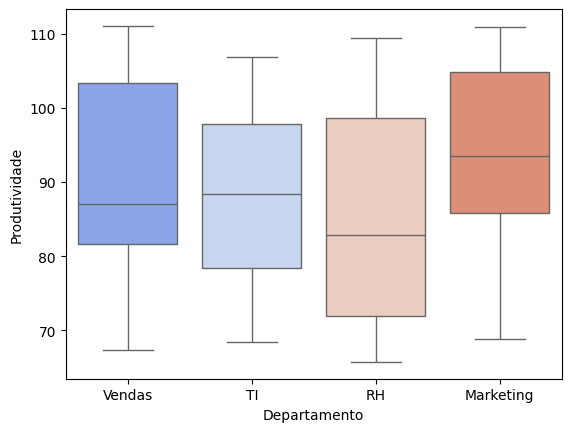

In [31]:
import seaborn as sns

sns.boxplot(data=dados, y='Produtividade', x='Departamento', palette='coolwarm');

In [32]:
# Ordinary Least Squares (OLS) model
model = ols('Produtividade ~ C(Departamento)', data=dados).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(Departamento),716.507759,3.0,1.443308,0.235017
Residual,15885.899500,96.0,NaN,NaN


**Conclusão: Não rejeitamos que a produtividade média é igual para todos os departamentos.**